In [2]:
# eda.ipynb – Cell 1: Load & Snapshot
import pandas as pd

# 1) Load the dataset
df = pd.read_csv("Combined_dataset.csv")

# 2) Raw snapshot
print("❖ Shape:", df.shape)
display(df.head())      # shows first 5 rows
df.info()               # shows dtypes & non-null counts
df.describe()           # shows mean, std, min, max for numeric cols


❖ Shape: (2827977, 14)


,Country,Area,Waterbody Type,Date,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Nitrogen (mg/l),Nitrate (mg/l),CCME_Values,CCME_WQI
0,Canada,SE649035-145565,River,12-01-1974,0.059248,1.30,8.1500,0.011917,8.07500,9.885,0.343917,11.73155,100.0,Excellent
1,Canada,SE649035-145565,River,12-01-1975,0.039821,1.38,7.8000,0.009417,7.73333,10.150,0.449083,11.82009,100.0,Excellent
2,Canada,SE649035-145565,River,12-01-1976,0.031341,2.23,7.8000,0.011000,7.46667,10.235,0.220750,14.87472,100.0,Excellent
3,Canada,SE649035-145565,River,12-01-1977,0.020501,1.61,8.1500,0.012333,7.78333,11.116,0.572250,15.89293,100.0,Excellent
4,Canada,SE649035-145565,River,12-01-1978,0.020023,1.64,4.3708,0.006182,7.10000,7.068,0.371091,15.22888,100.0,Excellent


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2827977 entries, 0 to 2827976
Data columns (total 14 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   Country                           object 
 1   Area                              object 
 2   Waterbody Type                    object 
 3   Date                              object 
 4   Ammonia (mg/l)                    float64
 5   Biochemical Oxygen Demand (mg/l)  float64
 6   Dissolved Oxygen (mg/l)           float64
 7   Orthophosphate (mg/l)             float64
 8   pH (ph units)                     float64
 9   Temperature (cel)                 float64
 10  Nitrogen (mg/l)                   float64
 11  Nitrate (mg/l)                    float64
 12  CCME_Values                       float64
 13  CCME_WQI                          object 
dtypes: float64(9), object(5)
memory usage: 302.1+ MB


,Ammonia (mg/l),Biochemical Oxygen Demand (mg/l),Dissolved Oxygen (mg/l),Orthophosphate (mg/l),pH (ph units),Temperature (cel),Nitrogen (mg/l),Nitrate (mg/l),CCME_Values
count,2.827977e+06,2.827977e+06,2.827977e+06,2.827977e+06,2.827977e+06,2.827977e+06,2.827977e+06,2.827977e+06,2.827977e+06
mean,1.171360e+00,4.886554e+00,1.000798e+01,7.104658e-01,7.735931e+00,1.183934e+01,5.209531e+00,4.766794e+00,8.504668e+01
std,5.668927e+00,1.641363e+01,1.851052e+00,2.089436e+00,4.946871e-01,5.010197e+00,6.200423e+00,6.073781e+00,1.764665e+01
min,-5.000000e-03,-2.000000e+00,0.000000e+00,-4.000000e-03,-1.000000e+00,-5.260000e+00,0.000000e+00,0.000000e+00,3.130414e+01
25%,3.000000e-02,1.600000e+00,9.860000e+00,4.000000e-02,7.550000e+00,8.990000e+00,7.800000e-01,1.173000e+00,7.715349e+01
50%,5.500000e-02,2.700000e+00,1.020000e+01,1.070000e-01,7.780000e+00,1.146000e+01,4.000000e+00,4.500000e+00,9.059609e+01
75%,3.170000e-01,2.830000e+00,1.100000e+01,2.270000e-01,8.000000e+00,1.420000e+01,6.320000e+00,4.940000e+00,1.000000e+02
max,2.000000e+02,2.550000e+02,2.000000e+01,1.000000e+02,3.000000e+01,9.800000e+01,4.600000e+01,1.550000e+02,1.000000e+02


In [3]:
# eda.ipynb – Cell 2: Profile missingness & ranges
missing = df.isna().sum()
print("❖ Missing values per column:\n", missing)

ranges = df.agg(['min','max'])
print("\n❖ Min/Max per numeric column:\n", ranges)


❖ Missing values per column:
 Country                             0
Area                                0
Waterbody Type                      0
Date                                0
Ammonia (mg/l)                      0
Biochemical Oxygen Demand (mg/l)    0
Dissolved Oxygen (mg/l)             0
Orthophosphate (mg/l)               0
pH (ph units)                       0
Temperature (cel)                   0
Nitrogen (mg/l)                     0
Nitrate (mg/l)                      0
CCME_Values                         0
CCME_WQI                            0
dtype: int64

❖ Min/Max per numeric column:
     Country                                 Area Waterbody Type        Date  \
min  Canada  "THE TUNNEL" FENNEY COMPTON STP, FE            Bay  01-01-1953   
max     USA             foyal, TRUSKY STREAM_010   Transitional  31-12-2020   

     Ammonia (mg/l)  Biochemical Oxygen Demand (mg/l)  \
min          -0.005                              -2.0   
max         200.000                      

In [6]:

# # eda.ipynb – Cell 3: Statistical summary & categorical frequencies
import pandas as pd

# 1) Total data points & unique‐value counts
print("❖ Total rows:", len(df))
print("❖ Unique values per column:")
display(df.nunique().to_frame(name="Unique Count"))

# 2) Central tendency for numeric columns
numeric_cols = df.select_dtypes(include=['float64','int64']).columns
print("\n❖ Mean of numeric columns:")
display(df[numeric_cols].mean().to_frame(name="Mean"))
print("\n❖ Median of numeric columns:")
display(df[numeric_cols].median().to_frame(name="Median"))
print("\n❖ Mode of numeric columns:")
# .mode() can return multiple rows if there's a tie; we take the first row
display(df[numeric_cols].mode().iloc[0].to_frame(name="Mode"))

# 3) Top 5 most common values for each categorical column
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"\n❖ Top 5 frequent values in '{col}':")
    display(df[col].value_counts().head(5).to_frame(name="Count"))




❖ Total rows: 2827977
❖ Unique values per column:


,Unique Count
Country,5
Area,61689
Waterbody Type,12
Date,23876
Ammonia (mg/l),13987
Biochemical Oxygen Demand (mg/l),4717
Dissolved Oxygen (mg/l),16253
Orthophosphate (mg/l),10596
pH (ph units),4726
Temperature (cel),11536



❖ Mean of numeric columns:


,Mean
Ammonia (mg/l),1.171360
Biochemical Oxygen Demand (mg/l),4.886554
Dissolved Oxygen (mg/l),10.007978
Orthophosphate (mg/l),0.710466
pH (ph units),7.735931
Temperature (cel),11.839341
Nitrogen (mg/l),5.209531
Nitrate (mg/l),4.766794
CCME_Values,85.046683



❖ Median of numeric columns:


...

,Count
Waterbody Type,
River,1852579
Effluent,601550
Lake,153603
Estuarine,49375
Bay,45997



❖ Top 5 frequent values in 'Date':


,Count
Date,
13-11-2008,922
12-03-2018,894
25-11-2013,881
19-11-2013,851
05-03-2014,837



❖ Top 5 frequent values in 'CCME_WQI':


,Count
CCME_WQI,
Good,1033709
Excellent,1020710
Marginal,328734
Fair,317856
Poor,126968


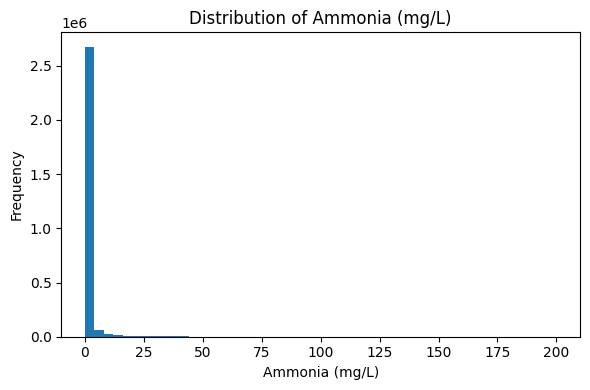

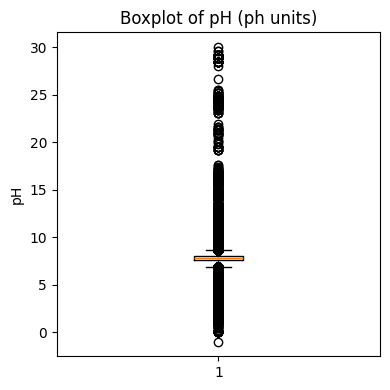

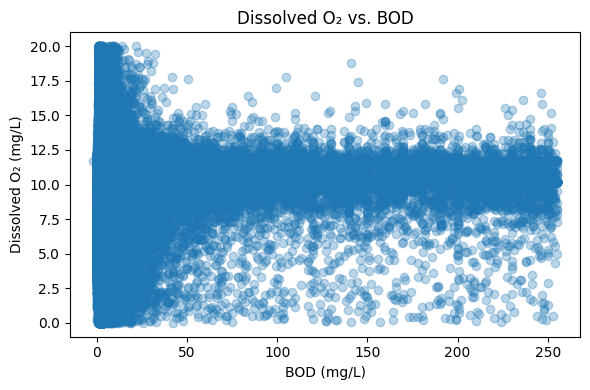

In [7]:
# eda.ipynb – Cell 4: Exploratory Visualizations

import matplotlib.pyplot as plt

# 1) Histogram of Ammonia concentrations
plt.figure(figsize=(6,4))
plt.hist(df['Ammonia (mg/l)'], bins=50)
plt.title("Distribution of Ammonia (mg/L)")
plt.xlabel("Ammonia (mg/L)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 2) Boxplot of pH values
plt.figure(figsize=(4,4))
plt.boxplot(df['pH (ph units)'].dropna(), vert=True)
plt.title("Boxplot of pH (ph units)")
plt.ylabel("pH")
plt.tight_layout()
plt.show()

# (Optional) 3) Scatterplot: DO vs. BOD
plt.figure(figsize=(6,4))
plt.scatter(df['Biochemical Oxygen Demand (mg/l)'],
            df['Dissolved Oxygen (mg/l)'],
            alpha=0.3)
plt.title("Dissolved O₂ vs. BOD")
plt.xlabel("BOD (mg/L)")
plt.ylabel("Dissolved O₂ (mg/L)")
plt.tight_layout()
plt.show()
